In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models
from sklearn.metrics import (precision_recall_fscore_support,
                             confusion_matrix, classification_report,
                             accuracy_score)
from sklearn.model_selection import StratifiedKFold
import numpy as np
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import timm
from PIL import Image
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [ ]:
# 3. SafeImageFolder (identical to KD notebook)
class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            return super(SafeImageFolder, self).__getitem__(index)
        except Exception as e:
            print(f"Skipping corrupted image at index {index}: {e}")
            return self.__getitem__((index + 1) % len(self))


In [ ]:
# 4. EarlyStopping (identical to KD notebook)
class EarlyStopping:
    def __init__(self, patience=10, verbose=True, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = float('inf')   # lower val_loss is better
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if val_loss < self.best_score:
            self.best_score = val_loss
            self.counter = 0
            self.save_checkpoint(val_loss, model)
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f"Validation Loss decreased. Saving model ...")
        torch.save(model.state_dict(), self.path)


In [ ]:
# 5. Transforms & Dataset  (identical augmentations to KD notebook)
DATA_DIR = "/content/drive/MyDrive/Research/PotatoDiseaseDataset/Potato Leaf Disease Dataset in Uncontrolled Environment"

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset (no transform yet — used for fold splitting only)
dataset = SafeImageFolder(DATA_DIR, transform=None)
class_names = dataset.classes
print(f"Classes detected: {class_names}")
print(f"Total samples  : {len(dataset)}")


Classes detected: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Total samples  : 3076


In [ ]:
class StudentNet(nn.Module):
    """Torchvision wrapper — kept for reference / size checks."""
    def __init__(self, num_classes):
        super().__init__()
        self.base = models.efficientnet_b0(pretrained=True)
        in_ch = self.base.classifier[1].in_features  # 1280
        self.base.classifier[1] = nn.Linear(in_ch, num_classes)

    def forward(self, x):
        return self.base(x)


In [ ]:
# 7. Mixup helper
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


In [ ]:
def train_baseline_model(model, train_loader, val_loader,
                         criterion, optimizer, scheduler,
                         num_epochs, device, early_stopping,
                         variant, output_dir):

    model.to(device)
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    train_precisions, train_recalls, train_f1s = [], [], []
    val_precisions,   val_recalls,   val_f1s   = [], [], []
    epoch_summaries = []

    for epoch in tqdm(range(num_epochs), desc="Epochs"):
        # ── Train ──────
        model.train()
        running_loss = 0.0
        correct = 0
        total   = 0
        all_preds, all_labels = [], []

        for images, labels in tqdm(train_loader,
                                   desc=f"Training Epoch {epoch+1}",
                                   leave=False):
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            images = images[valid_mask].to(device)
            labels = labels[valid_mask].to(device)

            # Mixup
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.4)

            outputs = model(images)

            # Pure CE loss with mixup
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / total if total > 0 else float('inf')
        train_acc  = 100 * correct / total if total > 0 else 0
        train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted', zero_division=0)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_precisions.append(train_precision)
        train_recalls.append(train_recall)
        train_f1s.append(train_f1)

        # ── Validate ────
        model.eval()
        val_loss    = 0.0
        val_correct = 0
        val_total   = 0
        val_preds, val_labels_list = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any():
                    continue
                images = images[valid_mask].to(device)
                labels = labels[valid_mask].to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total   += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_preds.extend(predicted.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        val_loss = val_loss / val_total if val_total > 0 else float('inf')
        val_acc  = 100 * val_correct / val_total if val_total > 0 else 0
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            val_labels_list, val_preds, average='weighted', zero_division=0)

        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_f1s.append(val_f1)

        epoch_summary = {
            'epoch':          epoch + 1,
            'train_loss':     train_loss,
            'train_accuracy': train_acc,
            'train_precision':train_precision,
            'train_recall':   train_recall,
            'train_f1':       train_f1,
            'val_loss':       val_loss,
            'val_accuracy':   val_acc,
            'val_precision':  val_precision,
            'val_recall':     val_recall,
            'val_f1':         val_f1
        }
        epoch_summaries.append(epoch_summary)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

        # Early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

        scheduler.step()

    # Save per-epoch CSV
    epoch_df  = pd.DataFrame(epoch_summaries)
    csv_path  = os.path.join(output_dir, f'baseline_epoch_summary_{variant}.csv')
    epoch_df.to_csv(csv_path, index=False)
    print(f"Saved epoch summaries to {csv_path}")

    # Restore best weights
    model.load_state_dict(torch.load(early_stopping.path))

    return model, epoch_df, (
        train_losses, val_losses,
        train_accs,   val_accs,
        train_precisions, train_recalls, train_f1s,
        val_precisions,   val_recalls,   val_f1s,
        val_labels_list,  val_preds
    )


In [ ]:
# 9. Evaluation helper
def evaluate_on_loader(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            images = images[valid_mask].to(device)
            labels = labels[valid_mask].to(device)
            outputs = model(images)
            preds   = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    return acc, precision, recall, f1


In [ ]:
# 10. 5-Fold Cross-Validation
OUTPUT_DIR = "/content/drive/MyDrive/Research/Model_save/EfficientNet_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# K-Fold setup
targets = [s[1] for s in dataset.samples]
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies, fold_precisions, fold_recalls, fold_f1s = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.arange(len(dataset)), targets)):
    print(f"\n========== Fold {fold+1}/5 ==========")

    # Apply transforms per fold
    train_data = SafeImageFolder(DATA_DIR, transform=train_transform)
    val_data   = SafeImageFolder(DATA_DIR, transform=val_transform)

    train_subset = Subset(train_data, train_idx)
    val_subset   = Subset(val_data,   val_idx)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)

    # Fresh student each fold — timm EfficientNet-B0
    student_model = timm.create_model(
        "efficientnet_b0", pretrained=True, num_classes=len(class_names)
    ).to(device)

    variant = f"baseline_fold{fold+1}"

    criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer     = torch.optim.AdamW(student_model.parameters(),
                                      lr=2e-4, weight_decay=1e-4)
    scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    early_stopping = EarlyStopping(
        patience=10, verbose=True,
        path=os.path.join(OUTPUT_DIR, f'baseline_fold{fold+1}_best.pt')
    )

    student_model, epoch_df, metrics = train_baseline_model(
        student_model, train_loader, val_loader,
        criterion, optimizer, scheduler,
        num_epochs=100, device=device,
        early_stopping=early_stopping,
        variant=variant,
        output_dir=OUTPUT_DIR
    )

    # Per-fold evaluation
    acc, precision, recall, f1 = evaluate_on_loader(student_model, val_loader, device)
    fold_accuracies.append(acc)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    print(f"Fold {fold+1} → Acc={acc:.4f}, P={precision:.4f}, R={recall:.4f}, F1={f1:.4f}")

# ── Cross-validation summary ──────
print("\n===== 5-Fold Cross Validation Results (Baseline EfficientNet-B0) =====")
print(f"Accuracy : {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Precision: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"Recall   : {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"F1 Score : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Best Fold Accuracy: {max(fold_accuracies):.4f}")

# Save CV results
results_df = pd.DataFrame({
    "Fold":      list(range(1, 6)),
    "Accuracy":  fold_accuracies,
    "Precision": fold_precisions,
    "Recall":    fold_recalls,
    "F1 Score":  fold_f1s
})
results_csv = os.path.join(OUTPUT_DIR, "crossval_baseline_efficientnet.csv")
results_df.to_csv(results_csv, index=False)
print(f"\nPer-fold metrics saved to: {results_csv}")


Using device: cuda

========== Fold 1/5 ==========


Epochs:   1%|          | 1/100 [00:50<1:22:36, 50.07s/it]

Epoch 1: Train Loss=2.2700, Train Acc=30.16%, Val Loss=1.5077, Val Acc=60.23%
Validation Loss decreased. Saving model ...



Epochs:   2%|▏         | 2/100 [01:39<1:21:00, 49.60s/it]

Epoch 2: Train Loss=1.5412, Train Acc=43.46%, Val Loss=1.2259, Val Acc=68.18%
Validation Loss decreased. Saving model ...


...


Epochs:  63%|██████▎   | 63/100 [51:56<30:55, 50.16s/it]

Epoch 63: Train Loss=0.8307, Train Acc=57.50%, Val Loss=0.7903, Val Acc=86.99%
EarlyStopping counter: 9 out of 10



Epochs:  63%|██████▎   | 63/100 [52:48<31:00, 50.30s/it]

Epoch 64: Train Loss=0.9147, Train Acc=63.23%, Val Loss=0.8243, Val Acc=86.02%
EarlyStopping counter: 10 out of 10
Early stopping triggered
Saved epoch summaries to /content/drive/MyDrive/Research/Model_save/EfficientNet_baseline/baseline_epoch_summary_baseline_fold5.csv


Fold 5 → Acc=0.8602, P=0.8646, R=0.8602, F1=0.8596

===== 5-Fold Cross Validation Results (Baseline EfficientNet-B0) =====
Accuracy : 0.8563 ± 0.0104
Precision: 0.8579 ± 0.0104
Recall   : 0.8563 ± 0.0104
F1 Score : 0.8557 ± 0.0103
Best Fold Accuracy: 0.8732

Per-fold metrics saved to: /content/drive/MyDrive/Research/Model_save/EfficientNet_baseline/crossval_baseline_efficientnet.csv


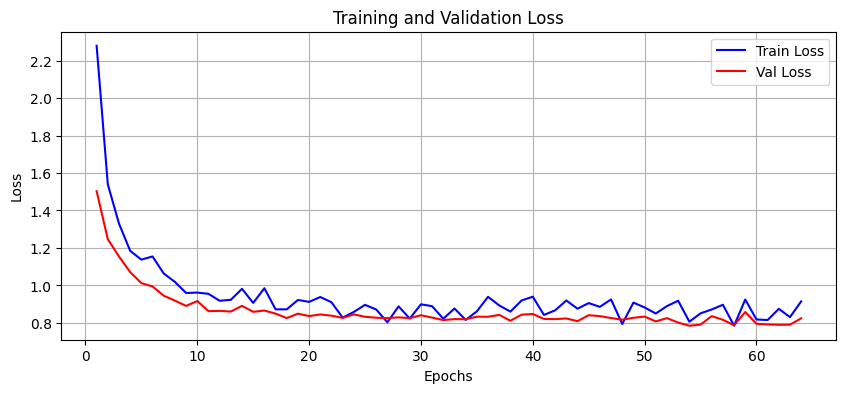

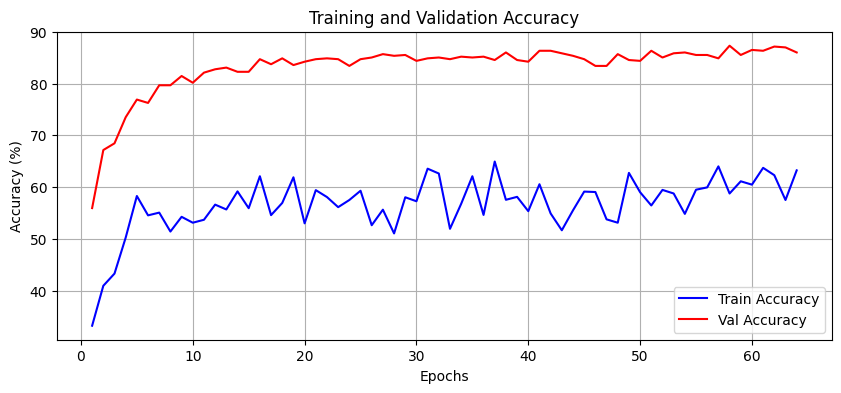

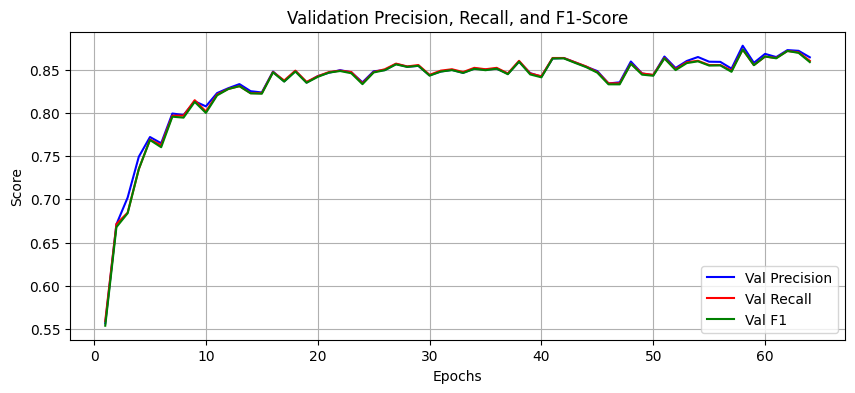

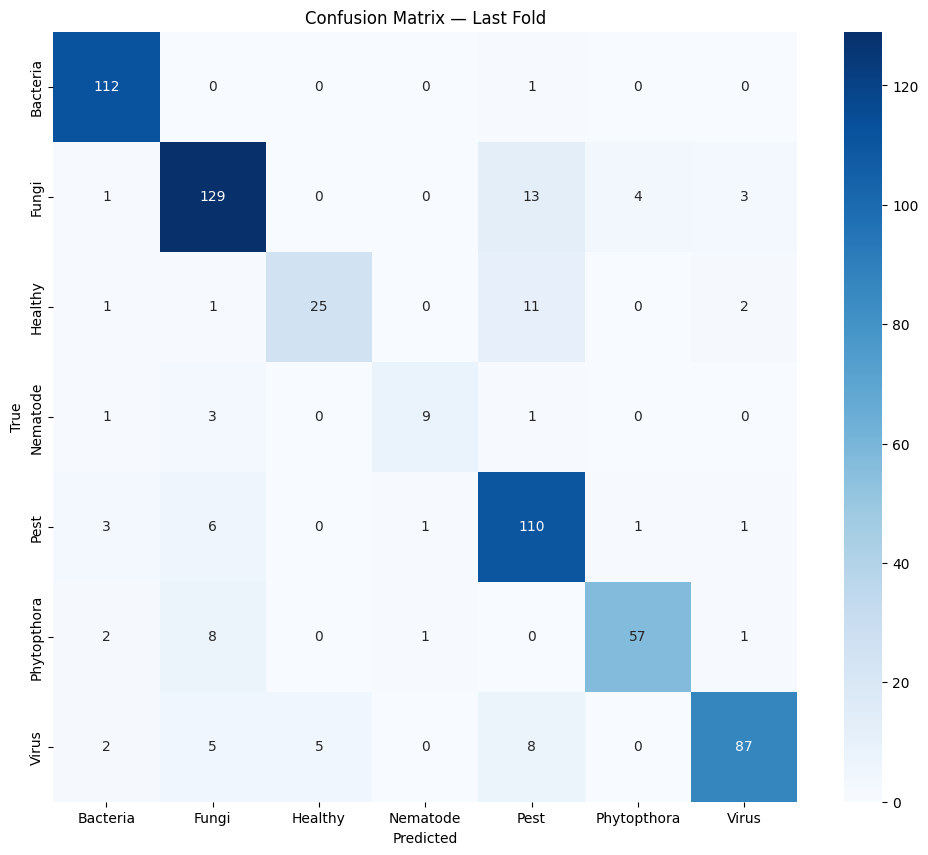

Classification Report:
              precision    recall  f1-score   support

    Bacteria       0.92      0.99      0.95       113
       Fungi       0.85      0.86      0.85       150
     Healthy       0.83      0.62      0.71        40
    Nematode       0.82      0.64      0.72        14
        Pest       0.76      0.90      0.83       122
 Phytopthora       0.92      0.83      0.87        69
       Virus       0.93      0.81      0.87       107

    accuracy                           0.86       615
   macro avg       0.86      0.81      0.83       615
weighted avg       0.86      0.86      0.86       615



In [ ]:
# 11. Training curves
(train_losses, val_losses,
 train_accs,   val_accs,
 train_precisions, train_recalls, train_f1s,
 val_precisions,   val_recalls,   val_f1s,
 val_labels_list,  val_preds) = metrics

def plot_metrics(variant, output_dir):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses,   'r-', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'loss_plot_{variant}.png'))
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_accs, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_accs,   'r-', label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'accuracy_plot_{variant}.png'))
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, val_precisions, 'b-', label='Val Precision')
    plt.plot(epochs, val_recalls,    'r-', label='Val Recall')
    plt.plot(epochs, val_f1s,        'g-', label='Val F1')
    plt.title('Validation Precision, Recall, and F1-Score')
    plt.xlabel('Epochs'); plt.ylabel('Score')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'prf1_plot_{variant}.png'))
    plt.show()

plot_metrics(variant, OUTPUT_DIR)

# Confusion Matrix
cm = confusion_matrix(val_labels_list, val_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Last Fold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.savefig(os.path.join(OUTPUT_DIR, f'confusion_matrix_{variant}.png'))
plt.show()

print("Classification Report:")
print(classification_report(val_labels_list, val_preds, target_names=class_names))


In [ ]:
# 10b. Full 5-Fold Detailed Summary Table
import pandas as pd

full_summary = pd.DataFrame({
    "Fold":           list(range(1, 6)),
    "Accuracy":       [f"{a:.4f}" for a in fold_accuracies],
    "Precision":      [f"{p:.4f}" for p in fold_precisions],
    "Recall":         [f"{r:.4f}" for r in fold_recalls],
    "F1 Score":       [f"{f:.4f}" for f in fold_f1s],
})

# Add mean and std rows
mean_row = {
    "Fold":      "Mean",
    "Accuracy":  f"{np.mean(fold_accuracies):.4f}",
    "Precision": f"{np.mean(fold_precisions):.4f}",
    "Recall":    f"{np.mean(fold_recalls):.4f}",
    "F1 Score":  f"{np.mean(fold_f1s):.4f}",
}
std_row = {
    "Fold":      "Std",
    "Accuracy":  f"{np.std(fold_accuracies):.4f}",
    "Precision": f"{np.std(fold_precisions):.4f}",
    "Recall":    f"{np.std(fold_recalls):.4f}",
    "F1 Score":  f"{np.std(fold_f1s):.4f}",
}

full_summary = pd.concat([
    full_summary,
    pd.DataFrame([mean_row]),
    pd.DataFrame([std_row])
], ignore_index=True)

# Display styled table
display(full_summary.style
    .set_caption("5-Fold Cross-Validation Summary — EfficientNet-B0 Baseline")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"), ("font-weight", "bold"), ("padding", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#4472C4"), ("color", "white"),
                   ("font-size", "13px"), ("text-align", "center"), ("padding", "8px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "8px"), ("font-size", "13px")]},
    ])
    .apply(lambda x: [
        "background-color: #D9E1F2; font-weight: bold" if x["Fold"] in ["Mean", "Std"]
        else "" for _ in x
    ], axis=1)
)

# Save to CSV
summary_csv = os.path.join(OUTPUT_DIR, "full_5fold_summary_baseline.csv")
full_summary.to_csv(summary_csv, index=False)
print(f"\nFull summary saved to: {summary_csv}")

,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.8571,0.8556,0.8571,0.8556
1,2,0.8439,0.8462,0.8439,0.8435
2,3,0.8472,0.8487,0.8472,0.8468
3,4,0.8732,0.8743,0.8732,0.8727
4,5,0.8602,0.8646,0.8602,0.8596
5,Mean,0.8563,0.8579,0.8563,0.8557
6,Std,0.0104,0.0104,0.0104,0.0103



Full summary saved to: /content/drive/MyDrive/Research/Model_save/EfficientNet_baseline/full_5fold_summary_baseline.csv


In [ ]:
# 12. Model size & inference speed
def get_model_size(model, save_path="temp_model.pth"):
    torch.save(model.state_dict(), save_path)
    size_mb = os.path.getsize(save_path) / 1e6
    os.remove(save_path)
    return size_mb

def measure_inference_speed(model, input_size=(1, 3, 224, 224),
                             device='cuda', num_runs=100):
    model.to(device)
    model.eval()
    dummy_input = torch.randn(input_size).to(device)
    for _ in range(10):          # warm-up
        _ = model(dummy_input)
    start = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(dummy_input)
    elapsed = time.time() - start
    return (elapsed / num_runs) * 1000, num_runs / elapsed

model_size = get_model_size(student_model)
inference_ms, fps = measure_inference_speed(student_model, device=device)

print("\nBaseline Student Model Efficiency:")
print(f"Model Size     : {model_size:.2f} MB")
print(f"Inference Speed: {inference_ms:.2f} ms/image ({fps:.2f} FPS)")



Baseline Student Model Efficiency:
Model Size     : 16.36 MB
Inference Speed: 8.89 ms/image (112.49 FPS)


In [ ]:
# 13. Inference on a random validation image
def predict_random_image(model, dataset_subset, transform, device, class_names):
    model.eval()
    idx        = random.randint(0, len(dataset_subset) - 1)
    image_path, true_label = dataset_subset.dataset.samples[dataset_subset.indices[idx]]
    print(f"Selected image: {image_path}")
    print(f"True label    : {class_names[true_label]}")
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Error loading image: {e}"); return
    tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs     = torch.softmax(model(tensor), dim=1)
        pred_idx  = torch.argmax(probs, dim=1).item()
        pred_prob = probs[0, pred_idx].item()
    print(f"Predicted     : {class_names[pred_idx]} ({pred_prob:.2%})")

predict_random_image(student_model, val_subset, val_transform, device, class_names)


Selected image: /content/drive/MyDrive/Research/PotatoDiseaseDataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Pest/20230712_145948.jpg
True label    : Pest
Predicted     : Fungi (60.91%)
